# Assignment 3:

This assignment consists of three parts:

* Part A - Machine Translation with T5
* Part B - Summarization Tests
* Part C - Summarization with LLMs

Each part can be worked on/run independently.  Each has its own setup section.

In addition to the notebook, make sure you download the data file named `train_plays-org-mod.txt` in the same directory as the Assignment_3.ipynb notebook. It is necessary to complete Part A.

## Part A - Machine Translation with T5

**Description:** This assignment notebook builds on the material from the
[lesson 6 notebook](https://colab.research.google.com/drive/1uWfmSHB1AGOw1ERNcQogsd57UjfWXqa7), in which we set up a new, very small version of a T5 encoder decoder model to train from scratch on translations from Shakespearean to Modern English. Since the model was trained from scratch, it didn't work very well. In this notebook, we'll first try to make that model work a little better, changing the model configuration and output generation parameters. Then we'll fine tune a small pre-trained T5 model on this task, to see how much better we can do with even a small pre-trained model. We'll apply several evaluation metrics, find some trade-offs, and try adding a secondary dataset to address some of the remaining challenges.

This notebook should be run on a Google Colab leveraging a GPU. By default, when you open the notebook in Colab it will try to use a GPU. Since colab is providing free access to a GPU they place constraints on that access.  Therefore you might want to turn off the GPU access (Edit -> Notebook Settings) while editing and initially debugging your code (at least the setup before you train each model). You will need a GPU to fully train or evaluate each of the models. Total runtime of the entire notebook (with solutions and a Colab GPU) should be about 1-2h, but potentially more depending on how much you experiment. If Colab tells you that you have reached your GPU limit, wait 10-24 hours and you should be able to access a GPU again.  It is your responsibility to manage your time and resources.



The overall structure for Part A is as follows:


3.0. Setup
  
  * 3.0.1 Libraries

  * 3.0.2 Data Acquisition

  * 3.0.3. Data Preparation


3.1. Tiny Seq2Seq Model Trained From Scratch
  
  * 3.1.1 Tokenizer and Model Setup

  * 3.1.2 Experimenting with Model Dimensions

  * 3.1.3 Text Generation Parameters

  * 3.1.4 Test Set Evaluation Metrics

3.2. Small Pre-Trained T5 Model

  * 3.2.1 Pre-Trained Model Setup and Tokenization

  * 3.2.2 Fine-Tuning the Pre-Trained Model

  * 3.2.3 Fine-Tuned Model Evaluation

  * 3.2.4 Style Classifier

  * 3.2.5 Revisit Decoder .Generate() Options

3.3. Adding Supplementary Paraphrase Dataset

  * 3.3.1 Load and preprocess the supplemental dataset

  * 3.3.2 Train T5 on Paraphrasing Task

  * 3.3.3 Fine-Tune Paraphrase-Trained Model on Main Task
  
  * 3.3.4 Paraphrase-Trained Model Evaluation


**INSTRUCTIONS:**

* Questions in this notebook are always indicated as **QUESTION**, so you can search for this string to make sure you answered all of the questions. You are expected to fill out, run, and submit this notebook, as well as to answer the questions in the Gradescope answers file. Please do not remove the output from your notebooks when you submit them as we'll look at the output as well as your code for grading purposes. We cannot award points if the output cells are empty.

* \### YOUR CODE HERE indicates that you are supposed to write code.

* If you want to, you can run all of the cells in section 0 in bulk. This is setup work and no questions are in there. At the end of section 0 we will state all of the relevant variables that were defined and created in section 1.

* Finally, unless otherwise indicated your validation accuracy will be 0.65 or higher if you have correctly implemented the model.

* \### --- Put your answer in Gradescope Q.0. Do not enter your answer here. --- ### indicates where in the Gradescope answer sheet you are supposed to write your answer. Please put your answer in the requested format. Some questions are multiple choice so you can select the appropriate answer. Other questions are fill in the blank so enter either a string or a raw number -- no executable code, for example "3,15,24" or 0.123 but NOT dict[23] or my_variable_name.

**GRADESCOPE:**

- We are **NOT** using the autograder for this assignment.

- We are using a Gradescope answer sheet to facilitate grading.

- The assignment notebook you submit must be named Assignment_3.ipynb. The very last question asks you to upload your notebook.

- Please format your input and output strings to be user friendly

- Adding comments in your code is strongly suggested but won't be graded.

- If you are stuck on a problem or do not understand a question - please come to office hours or ask questions (please don't post your code though). If it is a coding problem send a private email to your instructor.

- You can ask TAs for extra help and 1 on 1 sessions!

- You may use any libraries from the Python Standard Library for this assignment: https://docs.python.org/3/library/

**REMINDER:**
You must cite all of your uses of AI to assist in the homework.  A space is provided at the very end of the notebook to do so.

### 3.0. Setup


#### 3.0.1 Libraries

In [38]:
# This cell will authenticate you and mount your Drive in the Colab.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
!pip install -q  -U transformers
!pip install -q -U datasets
!pip install -q -U evaluate
!pip install -q tokenizers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 604.4/604.4 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 12.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cudf-cu13 26.6.0 requires pyarrow<24,>=19.0.0, but you have pyarrow 25.0.1 which is incompatible.


In [40]:
import re
import random
import numpy as np
from scipy.special import softmax

import torch
import transformers
import evaluate
from datasets import Dataset, load_dataset

# For from-scratch T5 model
from transformers import T5TokenizerFast, T5Config, T5ForConditionalGeneration

# For pre-trained T5 model
from transformers import T5Tokenizer, T5ForConditionalGeneration  # this won't import twice, just noting here what's for each model

# For all T5 models
from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

# For BLEURT (to load a trained model for evaluation)
from transformers import AutoModelForSequenceClassification, AutoTokenizer

# For style classifier model (also for evaluating the seq2seq model output)
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import TrainingArguments, Trainer

In [41]:
def print_version(library_name):
    try:
        lib = __import__(library_name)
        version = getattr(lib, '__version__', 'Version number not found')
        print(f"{library_name} version: {version}")
    except ImportError:
        print(f"{library_name} not installed.")
    except Exception as e:
        print(f"An error occurred: {e}")


In [42]:
#confirm versions
print_version('numpy')
print_version('torch')
print_version('transformers')
print_version('datasets')

numpy version: 2.1.3
torch version: 2.11.0+cu130
transformers version: 5.18.0
datasets version: 5.0.1


#### 3.O.2 Data Acquisition

We'll use the Shakespeare-to-Modern-English translation dataset from Lesson 6. The data includes aligned sentences from a number of plays by William Shakespeare.

The data was copied from this repo --[https://github.com/cocoxu/Shakespeare](https://github.com/cocoxu/Shakespeare) -- and consolidated into one file for easier handling.

You will to grab a copy from our git repo and import it to your Google drive.  From there you'll be able to easily load it in to a Colab notebook.

In [43]:
# Modify this path to the appropriate location in your Drive
text_file = 'drive/MyDrive/Colab Data/NLP266/assignment_3/train_plays-org-mod.txt'

#### 3.O.3 Data Preparation

Each line contains a Shakespearean sentence and its corresponding modern English translation.

The Shakesperean sentence is the *source sequence* and modern English one is the *target sequence*.

In [44]:
with open(text_file) as f:
    lines = f.read().split("\n")[:-1]

text_pairs = []
for line in lines:
    old, mod = line.split("\t")
    old = old
    mod = mod
    text_pairs.append((old, mod))

In [45]:
# Look at some examples
for _ in range(5):
    print(random.choice(text_pairs))

('Know That it was he, in the times past, which held you So under fortune, which you thought had been Our innocent self?', 'You know He was the one, in the times past, who held you back from promotion, and you thought it was our innocent self.')
('This was sometime a paradox, but now the time gives it proof.', 'This used to be contradictory, but now the time proves it’s true.')
('Come, sir.', 'Come with me, sir.')
('Tis a villain, sir, I do not love to look on.', 'It is a villain, sir, that I don’t like to look at.')
('Give me thy hand, Roderigo.', 'Give me your hand, Roderigo.')


In [46]:
# Let's create some splits
random.shuffle(text_pairs)
num_val_samples = int(0.06 * len(text_pairs))
num_train_samples = len(text_pairs) - 2 * num_val_samples
train_pairs = text_pairs[:num_train_samples]
val_pairs = text_pairs[num_train_samples : num_train_samples + num_val_samples]
test_pairs = text_pairs[num_train_samples + num_val_samples :]

print(f"{len(text_pairs)} total pairs")
print(f"{len(train_pairs)} training pairs")
print(f"{len(val_pairs)} validation pairs")
print(f"{len(test_pairs)} test pairs")

19088 total pairs
16798 training pairs
1145 validation pairs
1145 test pairs


Like we did in the lesson notebook, let's create a Huggingface dataset object from our data, so that it's easy to work with and pass to our model trainer.

In [47]:
def make_dataset(pairs):
    org_texts, mod_texts = zip(*pairs)
    org_texts = list(org_texts)
    mod_texts = list(mod_texts)

    dataset = Dataset.from_dict({"shakespeare": org_texts, "modern": mod_texts})
    return dataset.shuffle()

# Make the training data
train_dataset = make_dataset(train_pairs)

# Make the validation data
val_dataset = make_dataset(val_pairs)

### 3.1. Tiny Seq2Seq Model Trained From Scratch

As in the lesson 6 notebook, for our first model, we'll make a new tokenizer and model based on the T5 architecture, which we'll train from scratch only on our task dataset.



#### 3.1.1 Tokenizer and Model Setup

The easiest way to make a new tokenizer is to load an existing T5 one, then call .train_new_from_iterator(), providing our own dataset and vocab size.

In [48]:
VOCAB_SIZE = 15000

def get_word_piece_tokenizer(text_samples, vocab_size):

    base_tokenizer = T5TokenizerFast.from_pretrained('t5-base')
    new_tokenizer = base_tokenizer.train_new_from_iterator(
        text_samples,
        vocab_size=VOCAB_SIZE
    )

    return new_tokenizer

In [49]:
shakespeare_samples = [text_pair[0] for text_pair in train_pairs]
modern_samples = [text_pair[1] for text_pair in train_pairs]

part1_tokenizer = get_word_piece_tokenizer(shakespeare_samples + modern_samples, VOCAB_SIZE)

We'll need to preprocess the data using the tokenizer. Since our task is to translate from Shakespearean to Modern English, the Shakespeare text will be our input_ids and the Modern English will be the labels we use for training and evaluation. We'll create a function to do the tokenization, and then map it to our Huggingface datasets containing the train and validation data. We'll have the function take a tokenizer, because later we'll use a different pre-trained one.

In [50]:
MAX_SEQUENCE_LENGTH = 40

def preprocess_translation_batch(batch_text_pairs, tokenizer, prefix=""):
    if prefix:
        batch_text_pairs["shakespeare"] = [prefix + text for text in batch_text_pairs["shakespeare"]]

    shakespeare_encoded = tokenizer(
        batch_text_pairs["shakespeare"],
        max_length=MAX_SEQUENCE_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    modern_encoded = tokenizer(
        batch_text_pairs["modern"],
        max_length=MAX_SEQUENCE_LENGTH,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    return {'input_ids': shakespeare_encoded['input_ids'],
            'labels': modern_encoded['input_ids']}

In [51]:
train_ds_part1 = train_dataset.map(preprocess_translation_batch, batched=True,
                                   fn_kwargs={'tokenizer': part1_tokenizer})
val_ds_part1 = val_dataset.map(preprocess_translation_batch, batched=True,
                               fn_kwargs={'tokenizer': part1_tokenizer})

Map:   0%|          | 0/16798 [00:00<?, ? examples/s]

Map:   0%|          | 0/1145 [00:00<?, ? examples/s]

We'll need to create the new model from a config, specifying the model's dimensions. Then we'll need to make training arguments and trainer objects to be able to train the model. Let's create a function for each of those purposes, so that later we can use the functions to experiment with the available options.

First, make a function to create the model config and the model itself. Use the Lesson 6 notebook as a guide, and make sure to include all of the arguments that we've included in the function definition below. Those are what you'll experiment with next.

In [52]:
"""
Fill in the code to create a T5Config and new T5 model, using all of the function arguments
"""

def create_from_scratch_model(
    num_layers, #
    embed_dim, #
    keyvalue_dim, #
    dense_dim, #
    num_heads #
):

    ### YOUR CODE HERE

    t5_config = T5Config(
        vocab_size=VOCAB_SIZE, # Vocabulary size of the T5 model. Defines the number of different tokens that can be represented by the inputs_ids passed when calling T5Model.
        d_model=embed_dim, # Size of the encoder layers and the pooler layer.
        d_ff=dense_dim, # Size of the intermediate feed forward layer in each T5Block.
        d_kv=keyvalue_dim, #  Size of the key, query, value projections per attention head. The inner_dim of the projection layer will be defined as num_heads * d_kv.e
        num_layers=num_layers, # Number of hidden layers in the Transformer encoder.
        num_heads=num_heads, # Number of attention heads for each attention layer in the Transformer encoder.
        decoder_start_token_id=part1_tokenizer.pad_token_id,
    )
    t5_model = T5ForConditionalGeneration(t5_config)

    ### END YOUR CODE

    return t5_model

We'll also need to specify training arguments and a trainer for our model. Use the Seq2SeqTrainingArguments and Seq2SeqTrainer classes imported at the top of this notebook. You can use the Lesson 6 notebook as a guide for this too.

In [68]:
def create_seq2seq_training_args(batch_size, num_epochs):

    ### YOUR CODE HERE

    training_args = Seq2SeqTrainingArguments(
        "shakespeare_translation_model",
        eval_strategy='epoch',
        logging_strategy='epoch',
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=num_epochs,
        report_to='none'
    )


    ### END YOUR CODE

    return training_args

In [69]:
def create_seq2seq_trainer(model, training_args, train_ds, val_ds):

    ### YOUR CODE HERE

    trainer = Seq2SeqTrainer(
        model,
        training_args,
        train_dataset=train_ds,
        eval_dataset=val_ds,
    )
    ### END YOUR CODE

    return trainer

#### 3.1.2: Experimenting with Model Dimensions

In the Lesson 6 Notebook, we created a very small T5-style model with just one transformer layer and smaller dimensions for some of the internal layers. Now, you'll explore these options yourself, to see if you can get the model to work a little better when trained on this task.

Without adding any additional training data, can we configure the model to perform better when trained on this task? What happens if we add another one or more transformer layers to the encoder and decoder, or make some of the internal dimensions smaller or larger?

The T5Config gives us several hyperparameters to adjust the model's parameter dimensions. You can see the available arguments and their default values in the [T5Config documentation](https://huggingface.co/docs/transformers/v5.1.0/en/model_doc/t5).

We'll give you the batch size and num_epochs:


In [70]:
part1_batch_size = 64
part1_num_epochs = 30

Now you decide the rest.

Try changing the values for *num_layers* (number of transformer blocks), *d_model* (size of embedding and pooler layers), *d_kv* (size of query, key, and value vectors per attention head), *num_heads* (the number of attention heads), and *d_ff* (size of feed forward layers after each attention layer).

Find hyperparameters that finish training 30 epochs in 10-20 minutes on a free Colab T4 GPU, and that give you as low of a validation loss as you can, at least below 1.8. Also try to do this without overwhelming overfitting, i.e. try to keep training_loss / validation_loss > 0.6 after 30 epochs.

Then answer the questions below.

In [72]:
"""
Define the values you want to use for d_model, d_kv, num_heads, and d_ff, for the T5Config below.
"""

### YOUR CODE HERE

embed_dim = 256 # d_model (int, optional, defaults to 512) — Size of the encoder layers and the pooler layer.
keyvalue_dim = 64 # d_kv (int, optional, defaults to 64) — Size of the key, query, value projections per attention head. The inner_dim of the projection layer will be defined as num_heads * d_kv.
dense_dim = 2048 # d_ff (int, optional, defaults to 2048) — Size of the intermediate feed forward layer in each T5Block.
num_heads = 8 # num_heads (int, optional, defaults to 8) — Number of attention heads for each attention layer in the Transformer encoder.
num_layers = 4 # num_layers (int, optional, defaults to 6) — Number of hidden layers in the Transformer encoder.


### END YOUR CODE

In [73]:
part1_model = create_from_scratch_model(num_layers, embed_dim, keyvalue_dim, dense_dim, num_heads)
part1_training_args = create_seq2seq_training_args(part1_batch_size, part1_num_epochs)
part1_trainer = create_seq2seq_trainer(part1_model, part1_training_args,
                                       train_ds_part1, val_ds_part1)

part1_trainer.train()

Epoch,Training Loss,Validation Loss
1,2.727589,2.553961
2,2.437633,2.400234
3,2.318500,2.303145
4,2.232502,2.235540
5,2.161899,2.167695
6,2.100702,2.119171
7,2.048569,2.082185
8,2.004103,2.051510
9,1.963386,2.022605
10,1.929702,1.993972


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=7890, training_loss=1.8828326129792459, metrics={'train_runtime': 1003.8376, 'train_samples_per_second': 502.013, 'train_steps_per_second': 7.86, 'total_flos': 1776170314137600.0, 'train_loss': 1.8828326129792459, 'epoch': 30.0})

In [92]:

part1_trainer.state.log_history

[{'loss': 2.72758919023289,
  'grad_norm': 1.1135356426239014,
  'learning_rate': 4.833967046894804e-05,
  'epoch': 1.0,
  'step': 263},
 {'eval_loss': 2.5539610385894775,
  'eval_runtime': 0.7304,
  'eval_samples_per_second': 1567.628,
  'eval_steps_per_second': 24.644,
  'epoch': 1.0,
  'step': 263},
 {'loss': 2.4376334418815353,
  'grad_norm': 1.4448951482772827,
  'learning_rate': 4.667300380228137e-05,
  'epoch': 2.0,
  'step': 526},
 {'eval_loss': 2.4002339839935303,
  'eval_runtime': 0.6784,
  'eval_samples_per_second': 1687.829,
  'eval_steps_per_second': 26.534,
  'epoch': 2.0,
  'step': 526},
 {'loss': 2.318499779066659,
  'grad_norm': 1.3060535192489624,
  'learning_rate': 4.500633713561471e-05,
  'epoch': 3.0,
  'step': 789},
 {'eval_loss': 2.303145170211792,
  'eval_runtime': 0.7281,
  'eval_samples_per_second': 1572.647,
  'eval_steps_per_second': 24.723,
  'epoch': 3.0,
  'step': 789},
 {'loss': 2.2325021722017584,
  'grad_norm': 1.679886817932129,
  'learning_rate': 4.3

In [93]:
runtime = part1_trainer.state.log_history[-1]
final_val = part1_trainer.state.log_history[-2]
final_train = part1_trainer.state.log_history[-3]

final_train_loss = final_train['loss']
final_val_loss = final_val['eval_loss']
training_time = runtime['train_runtime']

print(f"Model Training Time: {training_time} seconds")
print("ACCEPTED" if training_time < 60*20 else "RETRY")
print(f"Final Train Loss: {final_train_loss}")
print(f"Final Validation Loss: {final_val_loss}")
print("ACCEPTED" if final_val_loss < 1.8 else "RETRY")
overfitting_ratio = final_train_loss / final_val_loss
print(f"Overfitting Ratio: {overfitting_ratio}")
print("ACCEPTED" if overfitting_ratio > 0.6 else "RETRY")


Model Training Time: 1003.8376 seconds
ACCEPTED
Final Train Loss: 1.63727352011793
Final Validation Loss: 1.7969752550125122
ACCEPTED
Overfitting Ratio: 0.9111274713165317
ACCEPTED


**QUESTION:**

 1.a (5 pt) What is the final validation loss that you were able to achieve for the part1 model after training for 30 epochs? (Copy and paste the decimal value for the final validation loss, to 5 significant digits, e.g. a number like 0.56781 or 0.87632. Put the answer in the answers cell; it should match the value shown in your output in this notebook.)



In [94]:
### --- Put your answer in Gradescope Q.1. Do not enter your answer here. --- ###
print(f"{final_val_loss:.5f}")

1.79698


**QUESTION:**

 3.1.b (4 pt) Which model config parameters (if any) did you increase, to achieve a lower validation loss, while staying within the training time and overfitting guidelines? (List the names of the parameters you increased, e.g. embed_dim, keyvalue_dim, num_heads, dense_dim, num_layers. Put this list in square brackets in the answers cell.)



In [95]:
### --- Put your answer in Gradescope Q.2. Do not enter your answer here. --- ###
print("None")

None


**QUESTION:**

 3.1.c (4 pt) Which model config parameters (if any) did you decrease, to achieve a lower validation loss, while staying within the training time and overfitting guidelines? (List the names of the parameters you decreased, e.g. embed_dim, keyvalue_dim, num_heads, dense_dim, num_layers. Put this list in square brackets in the answers cell.)

In [86]:
### --- Put your answer in Gradescope Q.3. Do not enter your answer here. --- ###
print("embed_dim: 512 -> 256")
print("num_layers: 6 -> 4")

embed_dim: 512 -> 256
num_layers: 6 -> 4


In [74]:
"""
Before moving on, save a checkpoint of the model you just trained in your Drive,
So that you can pick up where you left off later if needed
"""

# Modify this path to the location in your Drive where you want to save the part1 model
part1_model_checkpoint_filepath = 'drive/MyDrive/Colab Data/NLP266/assignment_3/part1_model'

In [75]:
# Run this line only after you've trained the part1 model
part1_model.save_pretrained(part1_model_checkpoint_filepath, from_pt=True)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [88]:
# Run this line only if you need to reload the model you trained earlier
part1_model = T5ForConditionalGeneration.from_pretrained(part1_model_checkpoint_filepath)

Loading weights:   0%|          | 0/89 [00:00<?, ?it/s]

#### 3.1.3: Text Generation Parameters

Cross-entropy loss is great for training, but it's not a very interpretable metric for manually reviewing how well the model is doing as we experiment with available options. Ultimately, we want to actually look at the translations the model outputs, compare them to human translations, and potentially judge other aspects of the actual output.

To do that, we need to actually generate some model output. Remember that the model itself predicts probabilities for each word in the vocabulary, based on what words have already been generated, at each decoder time-step. In order to select which actual words to output, there are multiple decoder strategies we can use that are build on top of the model's predicted probabilities. (E.g. beam search, top-k or top-p sampling, repeat ngram constraints, min/max length constraints, etc.)

Let's define a function below to generate translations for new inputs. Then we'll define another function to translate the validation set and calculate some standard evaluation metrics for translation, as well as print out some translations for manual inspection. We'll include some arguments that you'll experiment with next.

In [96]:
def generate_output(model, tokenizer, input_sentences, batch_size, **kwargs):

    all_outputs = []

    for i in range(int(len(input_sentences) / batch_size) + 1):
        start_i, end_i = i * batch_size, (i + 1) * batch_size
        if start_i >= len(input_sentences):
            break

        inputs_encoded = tokenizer(input_sentences[start_i:end_i], padding=True, return_tensors='pt')
        output_ids = model.cuda().generate(inputs_encoded['input_ids'].cuda(), **kwargs)
        generated_sentences = tokenizer.batch_decode(output_ids,
                                                     skip_special_tokens=True,
                                                     clean_up_tokenization_spaces=False)
        all_outputs.extend(generated_sentences)

    return all_outputs

In [97]:
# Load the BLEU metric and the trained BLEURT model for semantic similarity scoring

bleu = evaluate.load("bleu")

bleurt_tokenizer = AutoTokenizer.from_pretrained("Elron/bleurt-base-512")
bleurt_model = AutoModelForSequenceClassification.from_pretrained("Elron/bleurt-base-512")

config.json:   0%|          | 0.00/779 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/321 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

In [98]:
def calculate_eval_metrics(text_pairs, model, tokenizer, batch_size, prefix="", **kwargs):
    original_texts = [prefix + pair[0] for pair in text_pairs]
    label_texts = [pair[1] for pair in text_pairs]

    # Translate original texts
    translations = generate_output(model, tokenizer, original_texts, batch_size, **kwargs)

    # Calculate BLEU scores
    bleu_results = bleu.compute(predictions=translations, references=label_texts)
    print('BLEU: ', bleu_results)

    # Calculate BLEURT scores
    bleurt_scores = []
    for i in range(int(len(translations) / batch_size) + 1):
        start_i, end_i = i * batch_size, (i + 1) * batch_size
        if start_i >= len(translations):
            break

        with torch.no_grad():
            scores = bleurt_model(**bleurt_tokenizer(label_texts[start_i:end_i],
                                                     translations[start_i:end_i],
                                                     truncation=True,
                                                     max_length=MAX_SEQUENCE_LENGTH,
                                                     padding='max_length',
                                                     return_tensors='pt'))[0].squeeze().numpy()
            if scores.shape:
                bleurt_scores.extend(scores)
            else:  # Happens when there was only one example in the last batch
                bleurt_scores.append(float(scores))

    print('BLEURT: ', np.mean(bleurt_scores))

    return translations

First, choose some keyword arguments to pass to the generate_output() function. These can be any parameters for the .generate() method (e.g. beam search or top-k or top-p sampling, no_repeat_ngram_size, etc). You will want to try the options listed in Question 1.e below, to be able to answer that question (but some of them can't be used at the same time). More info on each can be found in the [Huggingface documentation on text generation here](https://huggingface.co/docs/transformers/en/main_classes/text_generation).

Then run the function to translate the validation set and print out eval metrics. The function returns the translations, so we'll also print out a sample of those to manually inspect. Use what you see to iterate on the .generate() arguments, trying to find the most reasonable .generate() arguments that you can for the model you trained.

The output will not be great no matter what you do, but you should be able to make it a little more readable, with slightly better BLEU and BLEURT metrics, than the basic options specified in the Lesson 6 notebook.

Then answer the questions below.

In [117]:
"""
Fill in the decoder .generate() arguments that you want to use, like num_beams or top_p, etc.
"""

part1_generate_kwargs = {

    ### YOUR CODE HERE
    "num_beams":4,
    "temperature":1,
    "top_k":20,
    "early_stopping":True,
    "no_repeat_ngram_size":3,



    ### END YOUR CODE
}

part1_val_translations = calculate_eval_metrics(
    val_pairs,
    part1_model,
    part1_tokenizer,
    part1_batch_size,
    **part1_generate_kwargs
)

/usr/local/lib/python3.13/dist-packages/transformers/generation/utils.py:1954: UserWarning: Using the model-agnostic default `max_length` (=21) to control the generation length. We recommend setting `max_new_tokens` to control the maximum length of the generation.
  warnings.warn(


BLEU:  {'bleu': 0.0661911177516273, 'precisions': [0.4694986196455606, 0.1441888139627132, 0.049105145413870246, 0.016615541922290387], 'brevity_penalty': 0.7677995701681194, 'length_ratio': 0.7909974640743872, 'translation_length': 11229, 'reference_length': 14196}
BLEURT:  -0.83182806


In [118]:
# Print out a sample of outputs to manually review
for i in range(10):
    sample_i = random.choice(range(len(part1_val_translations)))
    print('Original:    ', val_pairs[sample_i][0])
    print('Reference:   ', val_pairs[sample_i][1])
    print('Translation: ', part1_val_translations[sample_i])
    print()

Original:     Five shillings to one on ’t, with any man that knows the statutes, he may stay him—marry, not without the Prince be willing, for indeed the watch ought to offend no man, and it is an offense to stay a man against his will.
Reference:    I’ll bet any man who knows the law five shillings to one on it.
Translation:  If he’s a man, for the man that he’s not to be on the man,

Original:     You may to me, and ’tis most meet you should.
Reference:    You may to me, and it is most proper you should.
Translation:  You’ll have to me, and you to me, you shall be a meet me to.

Original:     How shall I know thee again?
Reference:    How will I recognize you in the future?
Translation:  How shall I know you know that?

Original:     Why, 'tis found so.
Reference:    Why, that’s the coroner’s finding.
Translation:  Why, it is.

Original:     O dear son Edgar, The food of thy abusèd father’s wrath, Might I but live to see thee in my touch, I’d say I had eyes again!
Reference:    If I 

**QUESTION:**

 3.1.d (3 pt) What seems to be particularly bad about the part1 model's translations? (Choose one of the following options that you agree with most and put it in the answers cell.)

 - A. The model keeps repeating the same common words or phrases over and over, which don't produce very meaningful statements.

 - B. The model is generating pretty good modern English, but it's quite offensive.

 - C. The model's output has mostly the same meaning as the input, but with minor grammatical mistakes.

 - D. The model is making up elaborate narrative details that don't appear in the original text.



In [105]:
### --- Put your answer in Gradescope Q.4. Do not enter your answer here. --- ###
print("A")

A


**QUESTION:**

 3.1.e (4 pt) Which .generate() parameter seemed to help the most in addressing the main shortcoming(s) that you noticed in the part1 model's output? (Choose one of the following options and put it in the answers cell.)

 - A. num_beams
 - B. do_sample
 - C. top_k
 - D. top_p
 - E. temperature
 - F. no_repeat_ngram_size

In [115]:
### --- Put your answer in Gradescope Q.5. Do not enter your answer here. --- ###
print("F")

F


#### 3.1.4 Test Set Evaluation Metrics

Once you've settled on training hyperparameters that produce good validation loss, and generation options that produce the best output you can so far, go ahead and calculate evaluation metrics on the test set, to warp up this from-scratch model.

Then answer the questions below.

In [119]:
# Print out eval metrics for the part1_model on the test set

part1_test_translations = calculate_eval_metrics(
    test_pairs,
    part1_model,
    part1_tokenizer,
    part1_batch_size,
    **part1_generate_kwargs
)

BLEU:  {'bleu': 0.07408423184319401, 'precisions': [0.5111688811862122, 0.17054431338599718, 0.06225296442687747, 0.023016440314510365], 'brevity_penalty': 0.7007705159408238, 'length_ratio': 0.7376944385254635, 'translation_length': 10386, 'reference_length': 14079}
BLEURT:  -0.7861667


**QUESTION:**

 3.1.f (3 pt) What is the overall BLEU score that you achieved on the test set for the part1 model? (Copy and paste the decimal value for the overall BLEU score, to 5 significant digits, e.g. a number like 0.03671 or 0.09763. Put the answer in the answers cell; it should match the value shown in your output in this notebook.)



In [120]:
### --- Put your answer in Gradescope Q.6. Do not enter your answer here. --- ###
print(f"{0.07408423184319401:.5f}")

0.07408


**QUESTION:**

 3.1.g (3 pt) What is the mean BLEURT score that you achieved on the test set for the part1 model? (Copy and paste the decimal value for the mean BLEURT score, to 5 significant digits, e.g. a number like -1.12345 or -0.54321. Put the answer in the answers cell; it should match the value shown in your output in this notebook.)

In [121]:
### --- Put your answer in Gradescope Q.7. Do not enter your answer here. --- ###
print(f"{-0.7861667:.5f}")

-0.78617


### 3.2. Small Pre-Trained T5 Model

What if we use a model that has already been pre-trained to recognize English (at least modern English), even if it hasn't yet been trained for our particular translation task?

We'll use a T5 small model, which should be able to generate good modern English, but we'll need to train it to encode and translate Shakespearean text.



#### 3.2.1 Pre-trained Model Setup and Tokenization

The next two cells load the pre-trained model, and preprocess the data with the pre-trained tokenizer. Fill in the necessary code for each of these cells.

For preprocessing, you'll need to map the `preprocess_translation_batch` function that we created earlier to the `train_dataset` and `val_dataset`. Use the code from part 1 as an example, but now pass in the pretrained T5 tokenizer as a function keyward argument (kwarg). Also pass in the given task_prefix as the "prefix" kwarg for the preprocessing function.

In [123]:
"""
Load the pre-trained model and tokenizer
"""

t5_pretrained_checkpoint_name = 'google-t5/t5-small'

### YOUR CODE HERE

part2_tokenizer = AutoTokenizer.from_pretrained(t5_pretrained_checkpoint_name)
part2_model = T5ForConditionalGeneration.from_pretrained(t5_pretrained_checkpoint_name)


### END YOUR CODE

Loading weights:   0%|          | 0/131 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

In [124]:
"""
Preprocess the datasets using the pretrained tokenizer, and the given task_prefix.
Use the task_prefix as the "prefix" argument to the function preprocess_translation_batch().
"""

task_prefix = 'Translate Shakespeare to Modern English: '

train_ds_part2 = train_dataset.map(
    preprocess_translation_batch,
    batched=True,
    fn_kwargs={

        ### YOUR CODE HERE
        "tokenizer": part2_tokenizer,
        "prefix": task_prefix,
        ### END YOUR CODE

})

val_ds_part2 = val_dataset.map(preprocess_translation_batch,
    batched=True,
    fn_kwargs={

        ### YOUR CODE HERE
        "tokenizer": part2_tokenizer,
        "prefix": task_prefix,
        ### END YOUR CODE

})

Map:   0%|          | 0/16798 [00:00<?, ? examples/s]

Map:   0%|          | 0/1145 [00:00<?, ? examples/s]

#### 3.2.2 Fine-Tuning the Pre-Trained Model

Now create the training args and trainer to fine-tune this pre-trained model. We've given you part of the code: you'll use the same functions as above for `create_seq2seq_training_args` and `create_seq2seq_trainer`. Fill in the rest of the arguments that you need for this version of the model. Use the provided batch size and num_epochs.

In [128]:
"""
Create the training args and trainer for the pre-trained model.
Use the batch size and num_epochs provided below for this model.
"""

part2_batch_size = 32
part2_num_epochs = 4

part2_training_args = create_seq2seq_training_args(

    ### YOUR CODE HERE
    batch_size=part2_batch_size,
    num_epochs=part2_num_epochs,
    ### END YOUR CODE
)

part2_trainer = create_seq2seq_trainer(

    ### YOUR CODE HERE
    model=part2_model,
    training_args=part2_training_args,
    train_ds=train_ds_part2,
    val_ds=val_ds_part2,
    ### END YOUR CODE
)

Run the cell below to fine-tune the part2 model, then answer the following questions.

In [ ]:
part2_trainer.train()

**QUESTION:**

 3.2.a (5 pt) What is the final validation loss that you were able to achieve for the part2 model after training for 4 epochs? (Copy and paste the decimal value for the final validation loss, to 5 significant digits, e.g. a number like 0.56781 or 0.87632. Put the answer in the answers cell; it should match the value shown in your output in this notebook.)

In [ ]:
### --- Put your answer in Gradescope Q.8. Do not enter your answer here. --- ###

In [ ]:
"""
Before moving on, save a checkpoint of the model you just trained in your Drive,
So that you can pick up where you left off later if needed
"""

# Modify this path to the location in your Drive where you want to save the part2 model
part2_model_checkpoint_filepath = 'drive/MyDrive/ISchool/MIDS/266/model_checkpoints/part2_model'

In [ ]:
# Run this line only after you've fine-tuned the part2_model
part2_model.save_pretrained(part2_model_checkpoint_filepath, from_pt=True)

In [ ]:
# Run this line only if you need to reload the model you fine-tuned earlier
part2_model = T5ForConditionalGeneration.from_pretrained(part2_model_checkpoint_filepath)

#### 3.2.3 Fine-Tuned Model Evaluation

Now use the calculate_eval_metrics() function defined above to translate the test set and calculate evaluation metrics. Also print out a sample of the translated outputs. For now, use the same decoder .generate() kwargs that you chose for part1.

Then answer the questions below.

In [ ]:
# Print out eval metrics for the part2_model on the test set

part2_test_translations = calculate_eval_metrics(
    test_pairs,
    part2_model,
    part2_tokenizer,
    part2_batch_size,
    task_prefix,
    **part1_generate_kwargs
)

In [ ]:
# Print out a sample of the translated outputs to look at as well

for i in range(10):
    sample_i = random.choice(range(len(part2_test_translations)))
    print('Original:    ', test_pairs[sample_i][0])
    print('Reference:   ', test_pairs[sample_i][1])
    print('Translation: ', part2_test_translations[sample_i])
    print()

**QUESTION:**

 3.2.b (4 pt) What is the overall BLEU score that you achieved on the test set for the part2 model? (Copy and paste the decimal value for the overall BLEU score, to 5 significant digits, e.g. a number like 0.03671 or 0.09763. Put the answer in the answers cell; it should match the value shown in your output in this notebook.)


In [ ]:
### --- Put your answer in Gradescope Q.9. Do not enter your answer here. --- ###

**QUESTION:**

 3.2.c (4 pt) What is the mean BLEURT score that you achieved on the test set for the part2 model? (Copy and paste the decimal value for the mean BLEURT score, to 5 significant digits, e.g. a number like -1.12345 or -0.54321. Put the answer in the answers cell; it should match the value shown in your output in this notebook.)



In [ ]:
### --- Put your answer in Gradescope Q.10. Do not enter your answer here. --- ###

**QUESTION:**

 3.2.d (4 pt) What do you notice about the part2 model's output? It should be much better than the part1 model's output. But the translations still probably don't perfectly match the reference human translations. What does the part2 model seem to still be doing poorly? (Chose one of the following options that you agree with most, and put it in the answers cell.)

 - A. The generated translations are gibberish.

 - B. The generated translations are written in a far more casual style than the reference human translations.

 - C. The generated translations mean something completely different from the input text and reference translations.

 - D. The generated translations are too similar to the input text, and haven't been rephrased as much as the reference human translations

In [ ]:
### --- Put your answer in Gradescope Q.11. Do not enter your answer here. --- ###

#### 3.2.4 Style Classifier

Now that the model is able to output more coherent translations, we can start to get more picky about different aspects of the output. We should also make sure that our evaluation metrics are capturing everything we want to be able to assess and improve in the model's output.

One thing we're not capturing yet is if the output has the right **style**. This task is sort of a translation task, but since it's between two different forms of English, we can also think of it as a style transfer task.

BLEU might help a little with that, but when the model chooses different words from the human reference, it could do so in ways that are still good modern English or that are still too much like Shakespeare. BLEURT won't tell us anything about the style, as long as the meaning is still similar to the reference.

How can we tell whether the output has the right style? We could train a separate classification model to predict whether text is Shakespearean or modern English. We have the data to do it! We just need to repurpose our data for a classification problem.

Use the code below to train a BERT classifier to predict whether a sentence is Shakespearean or modern English. We're providing this code for you, because it's not the main task and not based on a similar example from class. We want you to use it as one of your evaluation metrics, to help you iterate on your models for the main task.

In [ ]:
def make_style_classifier_data(text_pairs):
    style_texts = [pair[0] for pair in text_pairs] + [pair[1] for pair in text_pairs]
    style_labels = [0 for pair in text_pairs] + [1 for pair in text_pairs]

    style_dataset = Dataset.from_dict({"text": style_texts, "label": style_labels})

    return style_dataset.shuffle()

style_train_ds = make_style_classifier_data(train_pairs)
style_valid_ds = make_style_classifier_data(val_pairs)

In [ ]:
bert_checkpoint_name = 'bert-base-cased'
bert_tokenizer = BertTokenizer.from_pretrained(bert_checkpoint_name)
bert_style_classifier_model = BertForSequenceClassification.from_pretrained(bert_checkpoint_name)

In [ ]:
def preprocess_style_text(data):
    return bert_tokenizer(
            data['text'],
            max_length=MAX_SEQUENCE_LENGTH,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True,
            return_tensors="pt"
        )

style_train_ds_preprocessed = style_train_ds.map(preprocess_style_text, batched=True)
style_valid_ds_preprocessed = style_valid_ds.map(preprocess_style_text, batched=True)

In [ ]:
style_classifier_batch_size = 32
style_classifier_num_epochs = 2

style_training_args = TrainingArguments(
    output_dir="bert_shakespeare_style_classifier",
    per_device_train_batch_size=style_classifier_batch_size,
    per_device_eval_batch_size=style_classifier_batch_size,
    num_train_epochs=style_classifier_num_epochs,
    eval_strategy="epoch",
    save_strategy="epoch",
    report_to='none'
)

In [ ]:
metric = evaluate.load('accuracy')

def compute_metrics(p):
    predictions, labels = p
    predictions = np.argmax(predictions, axis=1)
    return metric.compute(predictions=predictions, references=labels)

In [ ]:
style_trainer = Trainer(
    model=bert_style_classifier_model,
    args=style_training_args,
    train_dataset=style_train_ds_preprocessed,
    eval_dataset=style_valid_ds_preprocessed,
    compute_metrics=compute_metrics
)

In [ ]:
style_trainer.train()

In [ ]:
"""
Before moving on, save a checkpoint of the model you just trained in your Drive,
So that you can pick up where you left off later if needed
"""

# Modify this path to the location in your Drive where you want to save the style classifier
style_classifier_checkpoint_filepath = 'drive/MyDrive/ISchool/MIDS/266/model_checkpoints/style_classifier'

In [ ]:
# Run this line only after you've trained the style classifier model
bert_style_classifier_model.save_pretrained(style_classifier_checkpoint_filepath, from_pt=True)

In [ ]:
# Run this line only if you need to reload the style classifier you trained earlier
bert_style_classifier_model = BertForSequenceClassification.from_pretrained(style_classifier_checkpoint_filepath)

Now let's use the style classifier to classify the output from the Shakespeare translation model, using the test set from our main task. The function reports the average predicted probability of the positive class, which is the modern English style (and which is our goal for our main task model).

We should also classify the original Shakespearean text and the human translations from the test set, to compare the scores as references.

Run the next two cells of code, then answer the following questions.

In [ ]:
def get_modern_style_score(text):
  text_inputs = bert_tokenizer(
            text,
            max_length=MAX_SEQUENCE_LENGTH,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_token_type_ids=True,
            return_tensors="pt"
        )

  with torch.no_grad():
      logits = bert_style_classifier_model.cuda()(text_inputs['input_ids'].cuda(),
                                                  attention_mask=text_inputs['attention_mask'].cuda()).logits

  probs = softmax(logits.cpu().numpy(), axis=1)
  return np.mean(probs[:, 1])

In [ ]:
test_original_texts = [task_prefix + pair[0] for pair in test_pairs]
test_label_texts = [pair[1] for pair in test_pairs]

translations_score = get_modern_style_score(part2_test_translations)
reference_score = get_modern_style_score(test_label_texts)
shakespeare_score = get_modern_style_score(test_original_texts)

print("Modern style score for generated translations:  ", translations_score)
print("Modern style score for reference translations:  ", reference_score)
print("Modern style score for original Shakespeare:    ", shakespeare_score)

**QUESTION:**

 3.2.e (4 pt) What is the modern style classifier score that you got for the part2 model's generated translations? (Copy and paste the decimal value from the get_modern_style_score function above, to 5 significant digits, e.g. a number like 0.36712 or 0.97632. Put the answer in the answers cell; it should match the value shown in your output in this notebook.)



In [ ]:
### --- Put your answer in Gradescope Q.12. Do not enter your answer here. --- ###

**QUESTION:**

 3.2.f (4 pt) What is the modern style classifier score that you got for the human reference translations? (Copy and paste the decimal value from the get_modern_style_score function above, to 5 significant digits, e.g. a number like 0.36712 or 0.97632. Put the answer in the answers cell; it should match the value shown in your output in this notebook.)



In [ ]:
### --- Put your answer in Gradescope Q.13. Do not enter your answer here. --- ###

**QUESTION:**

 3.2.g (4 pt) What is the modern style classifier score that you got for the original Shakespeare text? (Copy and paste the decimal value from the get_modern_style_score function above, to 5 significant digits, e.g. a number like 0.36712 or 0.97632. Put the answer in the answers cell; it should match the value shown in your output in this notebook.)



In [ ]:
### --- Put your answer in Gradescope Q.14. Do not enter your answer here. --- ###

**QUESTION:**

 3.2.h (3 pt) What do you notice about differences between these scores, and what does that tell you about what the part2 model is doing? (Chose one of the following options that you agree with most, and put it in the answers cell.)

 - A. The part2 model is generating output that is way more modern, casual, and younger generation speak than the human translations.

 - B. The part2 model is generating output that looks about as modern as the human translations, even if it doesn't always mean the same thing.

 - C. The part2 model is generating output that is partly modernized, more modern than the original Shakespeare, but still not as modern as the human references.

 - D. The part2 model is generating output that is still pretty much the same style as the original Shakespeare text.

In [ ]:
### --- Put your answer in Gradescope Q.15. Do not enter your answer here. --- ###

#### 3.2.5 Revisit Decoder .Generate() Options

Now that we have one more evaluation metrics, let's go back to the decoder .generate() arguments we used before. Are there any arguments you want to change, to try to do better on this latest evaluation metric?

Try different options for the part2_generate_kwargs below, and run the two cells afterward with each set of choices to see how the evaluation metrics change.

Then answer the questions below.

In [ ]:
"""
Fill in the decoder .generate() arguments that you want to use for the part2 model, like num_beams or top_p, etc.
"""

part2_generate_kwargs = {

    ### YOUR CODE HERE




    ### END YOUR CODE
}

In [ ]:
# Print out eval metrics for the part2_model on the test set, with the new kwargs

part2_test_translations = calculate_eval_metrics(
    test_pairs,
    part2_model,
    part2_tokenizer,
    part2_batch_size,
    task_prefix,
    **part2_generate_kwargs
)

In [ ]:
# Calculate modern style scores for the part2 translations after using the new kwargs

translations_score = get_modern_style_score(part2_test_translations)

print("Modern style score for generated translations:  ", translations_score)

In [ ]:
# Print out a sample of the translated outputs with the revised .generate() parameters

for i in range(10):
    sample_i = random.choice(range(len(part2_test_translations)))
    print('Original:    ', test_pairs[sample_i][0])
    print('Reference:   ', test_pairs[sample_i][1])
    print('Translation: ', part2_test_translations[sample_i])
    print()

**QUESTION:**

 3.2.i (3 pt) Which decoder strategy seemed to increase the modern style score the most? (Choose one of the following options and put it in the answers cell.)

 - A. Using a stricter option to always choose the highest predicted possibility output (e.g. beam search, or small k or p when using sampling).

 - B. Using a looser sampling method to allow the model to choose more varied output (e.g. top-k or top-p rather than beam search, especially with higher k or p and/or higher temperature).



In [ ]:
### --- Put your answer in Gradescope Q.16. Do not enter your answer here. --- ###

**QUESTION:**

 3.2.j (3 pt) What happens to the other evaluation metrics when you try to increase the modern style score by varying the decoder strategy discussed in 2.i? (Choose one of the following options and put it in the answers cell.)

 - A. BLEU and BLEURT both seem to be positively correlated with the modern style score, when changing the decoder strategy.

 - B. BLEU and BLEURT both seem to be negatively correlated with the modern style score, when changing the decoder strategy.

 - C. BLEU seems to move with the modern style score, but BLEURT seems to go the other direction.

 - D. BLEURT seems to move with the modern style score, but BLEU seems to go the other direction.



In [ ]:
### --- Put your answer in Gradescope Q.17. Do not enter your answer here. --- ###

**QUESTION:**

 3.2.k (4 pt) Why do you think the relationship in question 3.2.j is happening? (Choose one of the following options and put it in the answers cell.)

 - A. A stricter decoder strategy makes the model more likely to output the best translation, which is good for BLEU, BLEURT, and modern style objectives.

 - B. A looser decoder strategy gives the model more freedom to find a good modern style translation, which should also end up saying more of the same things in the same way as the human translation.

 - C. A stricter decoder strategy makes the model more likely to output a translation that has correct exact words and style, increasing BLEU and modern style scores, but might not mean the same thing as the human translation.

 - D. A looser decoder strategy gives the model more freedom to choose more modern style words, which the pre-trained model is more familiar with, but that freedom can make the model less likely to end up with the exact same words or meaning as the human translation.

 - E. A stricter decoder strategy makes the model more likely to choose more of the exact same words as used in the dataset, but not necessarily in the same order, so the meaning and style don't end up being as close to the human translation.

In [ ]:
### --- Put your answer in Gradescope Q.18. Do not enter your answer here. --- ###

### 3.3. Adding Supplementary Paraphrase Dataset

Can we do anything else to make the model capable of rephrasing the input text more into a different style (i.e. modernizing it more fully away from the Shakespeare), but still keep the same meaning?

One related task that could help is a paraphrasing task. The [GLUE Microsoft Research Paraphrase Corpus (MRPC)](https://huggingface.co/datasets/nyu-mll/glue) dataset has pairs of sentences with labels indicating whether the two sentences are equivalent (i.e. they mean the same thing) or not.

We could use that data as an additional supporting task for our T5 model, to see if it helps our model get better at accurately rephrasing the input text into a differently worded output.



#### 3.3.1 Load and preprocess the supplemental dataset

Load the dataset from Huggingface and look at the contents

In [ ]:
mrpc_data = load_dataset('SetFit/mrpc', trust_remote_code=True)

In [ ]:
mrpc_data

In [ ]:

mrpc_data['train'].features['label']

Let's use just the pairs that are labeled as equivalent (correct paraphrases), and split the sentences to use the first as the model's input and second as the model's output. Then we can use that to train our T5 model to better generate rephrased statements in modern English with the same meaning as the input but in different words.

In [ ]:
mrpc_equiv_train = mrpc_data['train'].filter(lambda example: example['label'] == 1)
mrpc_equiv_valid = mrpc_data['validation'].filter(lambda example: example['label'] == 1)

Fill in the code below to encode sentence1 e.g. "text1" as the model's input and sentence2 e.g. "text2" as the model's output.

We will also add a different prefix for this supporting task, so make sure to add the prefix to the inputs in the function below. (You can use the preprocess_translation_batch function above as an example.)

In [ ]:
def preprocess_mrpc_for_paraphrase_generation(mrpc_ds, tokenizer, prefix):

    ### YOUR CODE HERE

    # if prefix: ...
    # input_encoded = ...
    # output_encoded = ...





    ### END YOUR CODE

    return {'input_ids': input_encoded['input_ids'],
            'labels': output_encoded['input_ids']}

Now map the preprocessing function to the MRPC train and validation datasets. Use the part2_tokenizer to preprocess the data, since we're using the same T5 pre-trained model checkpoint as in part 2. For the preprocessing function's "prefix" argument, use the paraphrase_prefix provided below.

In [ ]:
paraphrase_prefix = 'Paraphrase in modern English: '

### YOUR CODE HERE

# mrpc_paraphrase_train = ...
# mrpc_paraphrase_valid = ...






### END YOUR CODE

#### 3.3.2 Train T5 on Paraphrasing Task

Load a fresh copy of the pre-trained T5 model (using the same pre-trained model checkpoint as part2), so that we can train it first on the paraphrase task, and last on the main task data.

In [ ]:
"""
Load a new copy of the same pre-trained model (we'll use the same in tokenizer as part2)
"""

t5_pretrained_checkpoint_name = 'google-t5/t5-small'

### YOUR CODE HERE

# part3_model = ...



### END YOUR CODE

Now create the training args and trainer for the paraphrase task, and train the model. Use the `create_seq2seq_training_args` and `create_seq2seq_trainer` functions like before.

You'll be using the part3_model you just loaded, and the MRPC data you preprocessed. Use the batch_size and num_epochs provided for the paraphrase task below.

In [ ]:
"""
Create the training args and trainer for the paraphrase task.
"""

paraphrase_batch_size = 32
paraphrase_num_epochs = 4

### YOUR CODE HERE

# paraphrase_training_args = ...
# paraphrase_trainer = ...





### END YOUR CODE

In [ ]:
paraphrase_trainer.train()

#### 3.3.3 Fine-Tune Paraphrase-Trained Model on Main Task

Now create the training args and trainer for the main task. Use the `create_seq2seq_training_args` and `create_seq2seq_trainer` functions one more time.

You'll be using the same model that you just trained on the paraphrase task (part3_model). Use the batch size and num epochs provided below.

For training data, use the same data as part2: `train_ds_part2` and `val_ds_part2`. We're using the same pre-trained model checkpoint, i.e. the same tokenizer, and the same task prefix, so the data has already been preprocessed correctly.

In [ ]:
"""
Create the training args and trainer for the main task using the part3_model.
"""

part3_batch_size = 32
part3_num_epochs = 4

### YOUR CODE HERE

# part3_training_args = ...
# part3_trainer = ...






### END YOUR CODE

In [ ]:
part3_trainer.train()

In [ ]:
"""
Before moving on, save a checkpoint of the model you just trained in your Drive,
So that you can pick up where you left off later if needed
"""

# Modify this path to the location in your Drive where you want to save the part3 model
part3_model_checkpoint_filepath = 'drive/MyDrive/ISchool/MIDS/266/model_checkpoints/part3_model'

In [ ]:
# Run this line only after you've trained the part3 model on both tasks
part3_model.save_pretrained(part3_model_checkpoint_filepath, from_pt=True)

In [ ]:
# Run this line only if you need to reload the part3 model you trained earlier
part3_model = T5ForConditionalGeneration.from_pretrained(part3_model_checkpoint_filepath)

#### 3.3.4 Paraphrase-Trained Model Evaluation

Use the functions defined above to translate the test set and calculate the same set of evaluation metrics as used on the part2 model.

Use the same decoder .generate() arguments as part2 (`part2_generate_kwargs`), so that we can compare the part2 and part3 models as closely as possible.

Run the next three cells, then answer the questions below.

In [ ]:
# Print out eval metrics for the part3_model on the test set, with the new kwargs

part3_test_translations = calculate_eval_metrics(
    test_pairs,
    part3_model,
    part2_tokenizer,
    part3_batch_size,
    task_prefix,
    **part2_generate_kwargs
)

In [ ]:
# Calculate modern style scores for the part3 translations after using the new kwargs

translations_score = get_modern_style_score(part3_test_translations)

print("Modern style score for generated translations:  ", translations_score)

In [ ]:
# Print out a sample of the translated outputs to look at as well

for i in range(10):
    sample_i = random.choice(range(len(part3_test_translations)))
    print('Original:    ', test_pairs[sample_i][0])
    print('Reference:   ', test_pairs[sample_i][1])
    print('Translation: ', part3_test_translations[sample_i])
    print()

**QUESTION:**

 3.3.a (3 pt) What is the overall BLEU score that you achieved on the test set for the part3 model? (Copy and paste the decimal value for the overall BLEU score, to 5 significant digits, e.g. a number like 0.03671 or 0.09763. Put the answer in the answers cell; it should match the value shown in your output in this notebook.)



In [ ]:
### --- Put your answer in Gradescope Q.19. Do not enter your answer here. --- ###

**QUESTION:**

 3.3.b (3 pt) What is the mean BLEURT score that you achieved on the test set for the part3 model? (Copy and paste the decimal value for the mean BLEURT score, to 5 significant digits, e.g. a number like -1.12345 or -0.54321. Put the answer in the answers cell; it should match the value shown in your output in this notebook.)



In [ ]:
### --- Put your answer in Gradescope Q.20. Do not enter your answer here. --- ###

**QUESTION:**

 3.3.c (3 pt) What is the modern style classifier score that you got for the part3 model's generated translations? (Copy and paste the decimal value from the get_modern_style_score function above, to 5 significant digits, e.g. a number like 0.36712 or 0.97632. Put the answer in the answers cell; it should match the value shown in your output in this notebook.)


In [ ]:
### --- Put your answer in Gradescope Q.21. Do not enter your answer here. --- ###


**QUESTION:**

 3.3.d (5 pt) How do the part3 model's evaluation scores and output compare to the part2 model? Write a short answer about what you observe in the markdown cell below.

In [ ]:
### --- Put your answer in Gradescope Q.22. Do not enter your answer here. --- ###


## Part B - Summarization Tests

**Description:** This assignment covers summarization outputs. You will compare three different types of solutions, all using an encoder-decoder architecture. You should also be able to develop an intuition for:


* How well summarization systems work
* The effects of using different pre-training and fine-tuning checkpoints on outcomes
* The effects of hyperparameters on outcomes
* Evaluation of output using ROUGE



This notebook should be run on a Google Colab but it does not require a GPU. By default, when you open the notebook in Colab it will configure a GPU. You can run Part B without a GPU but this may result in longer waits. Summarization commands can take up to five minutes to run depending on the hyperparameters you use.

**You may want to restart the notebook before you work on this section**

The overall assignment structure is as follows:

3.4.0. Setup

    3.4.1. T5 for generic summarization

    3.4.2. Pegasus for headline summarization

    3.4.3. Pegasus for longer generation




**INSTRUCTIONS:**:

* Questions are always indicated as **QUESTION:**, so you can search for this string to make sure you answered all of the questions.

* **### YOUR CODE HERE** indicates that you are supposed to write code.



### 3.4.0. Setup

In [ ]:
!pip install -q sentencepiece

In [ ]:
!pip install -q transformers
!pip install -q accelerate

In [ ]:
!pip install -q torchinfo

In [ ]:
from torchinfo import summary

In [ ]:
!pip install -q evaluate
import evaluate

In [ ]:
!pip install -q rouge_score

In [ ]:
#let's make longer output readable without horizontal scrolling
from pprint import pprint

Let's leverage the pre-trained and fine tuned models on HuggingFace to demonstrate some capabilities with abstractive summarization and language generation.  They include models/checkpoints that were fine tuned on a particular dataset.  In our case we'll focus on one dataset that emphasizes a one line output and another that emphasizes a multi-line output.

We'll use this same toy article as the input to all of our summarization attempts.  That way we have the ability to compare. We'll also create two references for evaluation.  These are the targets you are trying to meet.  One reference is for the longer output. The second reference is the short one for the one line output.

In [ ]:

ARTICLE_TO_SUMMARIZE = (
    "Nearly 800 thousand customers are scheduled to be affected by the shutoffs which are expected to last through at least midday tomorrow. "
    "PG&E stated it scheduled the blackouts in response to forecasts for high winds amid dry conditions. "
    "The aim is to reduce the risk of wildfires. "
    "If Pacific Gas & Electric Co, a unit of PG&E Corp, goes through with another public safety power shutoff, "
    " it would be the fourth round of mass blackouts imposed by the utility since Oct. 9, when some 730,000 customers were left in the dark. "
    "The recent wave of precautionary shutoffs have drawn sharp criticism from Governor Gavin Newsom, state regulators and consumer activists as being overly broad in scale."
    "Newsom blames PG&E for doing too little to properly maintain and secure its power lines against wind damage."
    "Utility executives have acknowledged room for improvement while defending the sprawling scope of the power cutoffs as a matter of public safety."
    "The record breaking drought has made the current conditions even worse than in previous years. "
    "It exponentially increases the probability of large scale wildfires. "
)

LONG_REFERENCE = (
    "Many PG&E customers could be affected by public safety power shutoffs in response to forecasts for high winds and dry conditions. "
    "The record breaking drought exponentially increases the probability of large scale wildfires. "
    "Despite being criticized by Governor Newsom for being overly broad, company officials defend the cutoffs as a matter of public safety. "
)

SHORT_REFERENCE = (
    "California's largest utility is set to turn off power to hundreds of thousands of customers in an effort to reduce the risk of wildfires. "
)

How long is our article to summarize?  Obviously our summary should be shorter since it is supposed to be "abridged."

In [ ]:
len(str.split(ARTICLE_TO_SUMMARIZE))

### 3.4.1. T5 for Generic Summarization

T5 is an encoder decoder architecture that has been trained on multiple tasks, so not purely summarization.  You can read more about it [here](https://huggingface.co/docs/transformers/model_doc/t5).

In [ ]:
#Load model directly
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

t5_tokenizer = AutoTokenizer.from_pretrained("google-t5/t5-base")
t5_model = AutoModelForSeq2SeqLM.from_pretrained("google-t5/t5-base")

Since T5 can perform multiple tasks we need to tell it what kind of output we want.  Therefore we need to prepend a "prompt" to our article text to make sure it does the right thing.

In [ ]:
PROMPT = 'summarize: '
T5ARTICLE_TO_SUMMARIZE = PROMPT + ARTICLE_TO_SUMMARIZE

In [ ]:
inputs = t5_tokenizer(T5ARTICLE_TO_SUMMARIZE, max_length=1024, truncation=True, return_tensors="pt")

What do the inputs look like?  How does it compare with what we've seen from BERT?

In [ ]:
inputs

Let's just run T5 using it's default hyperparameters and see what happens.  We'll hold on to the output in the candidate variable.  What do you think about the output?

In [ ]:
# Generate Summary
summary_ids = t5_model.generate(inputs["input_ids"],
                               max_new_tokens=30
)
candidate = t5_tokenizer.batch_decode(summary_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
pprint(candidate[0], compact=True)

#### 3.4.1.a Checkpoint Configuration

We're using the `t5-base` configuration and we know we can run out of the box to do summarization which means it has some hyperparameters set as defaults.  These may or may not be what we want to use.  How do we know which values are set as defaults?

HuggingFace provides access to the default hyperparameters via the AutoConfig object which we call below.  We simply pass in the name of the checkpoint we're using -- `t5-base` in this case.


In [ ]:
from transformers import AutoConfig

config = AutoConfig.from_pretrained("t5-base")

config

Look at the `task_specific_params` for summarization. You can see that this `t5-base` checkpoint has some values such as min_length and max_length as well as no_repeat_ngram_size and num_beams.  You can affect the size and content of the output by modifying these parameters which you will do below.

You can also look at the full set of possible parameters in the [TFGenerationMixin](https://huggingface.co/docs/transformers/v4.18.0/en/main_classes/text_generation#transformers.generation_tf_utils.TFGenerationMixin) class available to all of the pre-trained models.

HuggingFace has also written [a very helpful blog post](https://huggingface.co/blog/how-to-generate) that explains and discusses various strategies for text generation and how to manipulate the hyperparameters.  They discuss the two approaches of beam search (which we have discussed in the async and live session) as well as sampling (which tries to randomly pick the next word within a k-sized distribution of highly probable choices).

**Please read the blog post before you proceed.**

For your reference, here's a more complex, technical, and thorough [HuggingFace guide](https://huggingface.co/docs/transformers/main/en/generation_strategies) for controlling generation of text.  The blog post above is all you need to read to complete the assignment.

#### 3.4.1.b ROUGE for summarization evaluation

ROUGE is the metric that has been traditionally used to evaluate sumarization results.  The ROUGE metric expects a reference as input and it will evaluate a candidate against that reference.  ROUGE-1 calculates the number of words in the reference that occur in the candidate.  ROUGE-2 performs that same calculation but for bigrams in the reference. ROUGE-L calculates the longest common subsequence of reference words that occur in the candidate.

HuggingFace provides a wrapper around [a library](https://huggingface.co/spaces/evaluate-metric/rouge) to calculate ROUGE metrics which you will use below.  Let's calculate the ROUGE score for the candidate you produced above.

In [ ]:
rouge = evaluate.load('rouge')
predictions = candidate
references = [SHORT_REFERENCE]
results = rouge.compute(predictions=predictions,
                        references=references)
print(results)

Let's experiment with the hyperparameters shown above.  Please experiment in the cell below.  The `num_beams` value is like a beam search.  It indicates the number of tries the model makes before showing you its best output.  The `no_repeat_ngram_size` is designed to help reduce repetition in the output.  `min_length` and `max_length` (or now `max_new_tokens`) set boundaries on the size of the summary. You are free to use other hyperparameters as described in the [blog post](https://huggingface.co/blog/how-to-generate).

*There is no one correct answer to these questions.  There are ranges that tend to work better than others.  The goal is to have you experiment to help build intuition.  Please enter the values that you think are generating the most readable output.*

*Your readable output should consist of at least one complete sentence but does not have to end with a period and you must also have a ROUGE-1 score above 0.30 and ROUGE-L score equal to or above 0.25 when compared with the short reference.*

You can use the two cells below to come up with your answer.

In [ ]:
# Generate Summary
summary_ids = t5_model.generate(inputs["input_ids"],
### YOUR CODE HERE



### END YOUR CODE
)

candidate = t5_tokenizer.batch_decode(summary_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
pprint(candidate[0], compact=True)

In [ ]:
predictions = candidate
references = [SHORT_REFERENCE]
results = rouge.compute(predictions=predictions,
                        references=references)
print(results)

**QUESTION:**

3.4.1.1 (2 pt) Which max_new_tokens value gives the most readable output that meets the score criteria?



In [ ]:
### --- Put your answer in Gradescope Q.23. Do not enter your answer here. --- ###

**QUESTION:**

3.4.1.2 (2 pt) What is the ROUGE-L score associated with your most readable candidate?

In [ ]:
### --- Put your answer in Gradescope Q.24. Do not enter your answer here. --- ###

In [ ]:
#In order to not consume all of the memory available in Colab we'll free up the memory we're using for these large language models
del t5_model
del t5_tokenizer


### 3.4.2. Pegasus for Headline Summarization

Pegasus is an encoder decoder architecture that has been explicitly pre-trained as an abstractive summarizer.  You can read more about it [here](https://huggingface.co/docs/transformers/model_doc/pegasus) and [here](https://arxiv.org/pdf/1912.08777.pdf).

We'll first use the `google/pegasus-xsum` checkpoint.  It is trained on a [summarization task](https://aclanthology.org/D18-1206.pdf) that reads a news article and then [emits a one line summary](https://huggingface.co/datasets/xsum).  This doesn't mean that it is limited in its output length.  It does mean that it works well with news article type inputs and tends toward shorter outputs.

In [ ]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

ptokenizer = AutoTokenizer.from_pretrained("google/pegasus-xsum")
pmodel = AutoModelForSeq2SeqLM.from_pretrained("google/pegasus-xsum")

In [ ]:
summary(pmodel)

Let's see what kinds of default parameters are configured in to this checkpoint.

In [ ]:
config = AutoConfig.from_pretrained("google/pegasus-xsum")

config

Generate the inputs using the pegasus tokenizer for this checkpoint.

In [ ]:
inputs = ptokenizer(ARTICLE_TO_SUMMARIZE, max_length=1024, truncation=True, return_tensors="pt")

Let's get some output using just the default values and see what we're working with.

In [ ]:
# Generate Summary
summary_ids = pmodel.generate(inputs["input_ids"]
)
pprint(ptokenizer.batch_decode(summary_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0], compact=True)

Let's experiment with the same set of hyperparameters for the Pegasus system.  It is designed for abstractive summarization. Remember that the checkpoint we are using was trained on data that generates a one line summary for the input article.

*Your readable output should consist of at least one complete sentence but does not have to end with a period and you must also have a ROUGE-1 score above 0.70 and ROUGE-L score equal to or above 0.65 when compared with the short reference.*

You can use the two cells below to experiment with hyperparameters and generating and scoring your outputs in order to answer questions 3.4.2.1 - 3.4.2.5 in your answers cell.




In [ ]:
# Generate Summary
summary_ids = pmodel.generate(inputs["input_ids"],
### YOUR CODE HERE





### END YOUR CODE
)
candidate = ptokenizer.batch_decode(summary_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
pprint(candidate[0], compact=True)

In [ ]:
rouge = evaluate.load('rouge')
predictions = candidate
references = [SHORT_REFERENCE]
results = rouge.compute(predictions=predictions,
                        references=references)
print(results)

**QUESTION:**

3.4.2.1 (2 pt) Which max_new_tokens value gives the most readable output that meets the score criteria?



In [ ]:
### --- Put your answer in Gradescope Q.25. Do not enter your answer here. --- ###

**QUESTION:**

3.4.2.2 (2 pt) What is the ROUGE-L score associated with your most readable candidate?

In [ ]:
### --- Put your answer in Gradescope Q.26. Do not enter your answer here. --- ###

Delete that Pegasus model and tokenizer so we can load the next one.

In [ ]:
del pmodel
del ptokenizer

### 3.4.3. Pegasus for Longer Generation

Now let's try to produce a longer summary of our article.  In order to do that we are going to use a different fine-tuned checkpoint for Pegasus.  This checkpoint is fine-tuned on the [Newsroom
](https://huggingface.co/datasets/newsroom) set of news articles.  The references are on the order of several sentences long.

In [ ]:
# Load model directly
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

cnntokenizer = AutoTokenizer.from_pretrained("google/pegasus-newsroom")
cnnmodel = AutoModelForSeq2SeqLM.from_pretrained("google/pegasus-newsroom")

Let's see how this checkpoint is configured by default:

In [ ]:
config = AutoConfig.from_pretrained("google/pegasus-newsroom")

config

Let's tokenize our input for this checkpoint.

In [ ]:
cnninputs = cnntokenizer(ARTICLE_TO_SUMMARIZE, max_length=1024, truncation=True, return_tensors="pt")

Run the summarizer with the defaults and let's see what it looks like.

In [ ]:
# Generate Summary
summary_ids = cnnmodel.generate(inputs["input_ids"]
)

pprint(cnntokenizer.batch_decode(summary_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)[0], compact=True)

Let's again experiment with the same set of hyperparameters (but possibly with different values) for the Pegasus system.  It is designed for abstractive summarization and this checkpoint is based on multi-line outputs.  We'll evaluate it against the long reference record.

*Your readable multi-line output must have a ROUGE-1 score above 0.35 and a ROUGE-L score above 0.20.*

You can use the two cells below to experiment with hyperparameters and generating and scoring your outputs in order to answer questions 3.4.3.1 - 3.4.3.5 in your answers cell.





In [ ]:
# Generate Summary
summary_ids = cnnmodel.generate(cnninputs["input_ids"],
### YOUR CODE HERE









### END YOUR CODE
                             )
candidate = cnntokenizer.batch_decode(summary_ids, skip_special_tokens=True, clean_up_tokenization_spaces=False)
pprint(candidate[0], compact=True)

In [ ]:
rouge = evaluate.load('rouge')
predictions = candidate
references = [LONG_REFERENCE]
results = rouge.compute(predictions=predictions,
                        references=references)
print(results)

**QUESTION:**

3.4.3.1 (2 pt) Which max_new_tokens value gives you the most readable output that meets the score criteria?



In [ ]:
### --- Put your answer in Gradescope Q.27. Do not enter your answer here. --- ###

**QUESTION:**

3.4.3.2 (2 pt) What is the ROUGE-L score associated with your most readable candidate?

In [ ]:
### --- Put your answer in Gradescope Q.28. Do not enter your answer here. --- ###

Okay, you're done with Part B.

Which model do you think produced the best summaries keeping in mind that best is in the eye of the reader?

## Part C - Summarization with LLMs

**Description:** This part covers the task of summarization which is the process of generating an abridged version of the input. With the ascendance of LLMs, we have a new way of generating summaries. Now, rather than fine-tuning to generate summaries, we can simply provide explicit instructios for the summary we want the model to generate.  By finishing this assignment you should also be able to develop an intuition for:


* How well summarization systems work
* The effects of hyperparameters on outcomes
* The effects of prompts on the output of an LLM
* Evaluation of output using ROUGE



This notebook must be run on a Google Colab as it requires a GPU. By default, when you open the notebook in Colab it will configure a GPU.  Summarization commands can take up to five minutes to run depending on the hyperparameters you use.


The overall part C structure is as follows:

3.5.0. Setup

3.5.1. Gemma 2 for abstractive summarization


**YOU MUST RESTART THE NOTEBOOK BEFORE PROCEEDING**
or you will run out of GPU memory




**INSTRUCTIONS:**:

* Questions are always indicated as **QUESTION:**, so you can search for this string to make sure you answered all of the questions. You are expected to fill out, run, and submit this notebook, as well as to answer the questions in the **answers** file as you did in a1 and a2.

* **### YOUR CODE HERE** indicates that you are supposed to write code.


* In order to complete the assignment with the Gemma model you will need to get an account on [Hugging Face](https://huggingface.co).  It is free.  Once you have the account on Hugging Face you will need to create an Access Token.  Go
to Access Token under your profile and generate a token with write permissions for colab.  You will need to copy that token and add it to the secrets in your Colab account with the name `HF_TOKEN` and the value of the string of your access token.

* In addition, you will need to visit the [Model Card for the Gemma 2 model](https://huggingface.co/google/gemma-2-9b-it).  At the top of the page you will see a notice saying you need to request perrmission to use the model.  While logged in to your Hugging Face account, click the button to request permission.  It can sometimes take up to 10 or 15 minutes to get approved.  Once you are approved the message on the Model Card will change to indicate you have been granted access to the model.

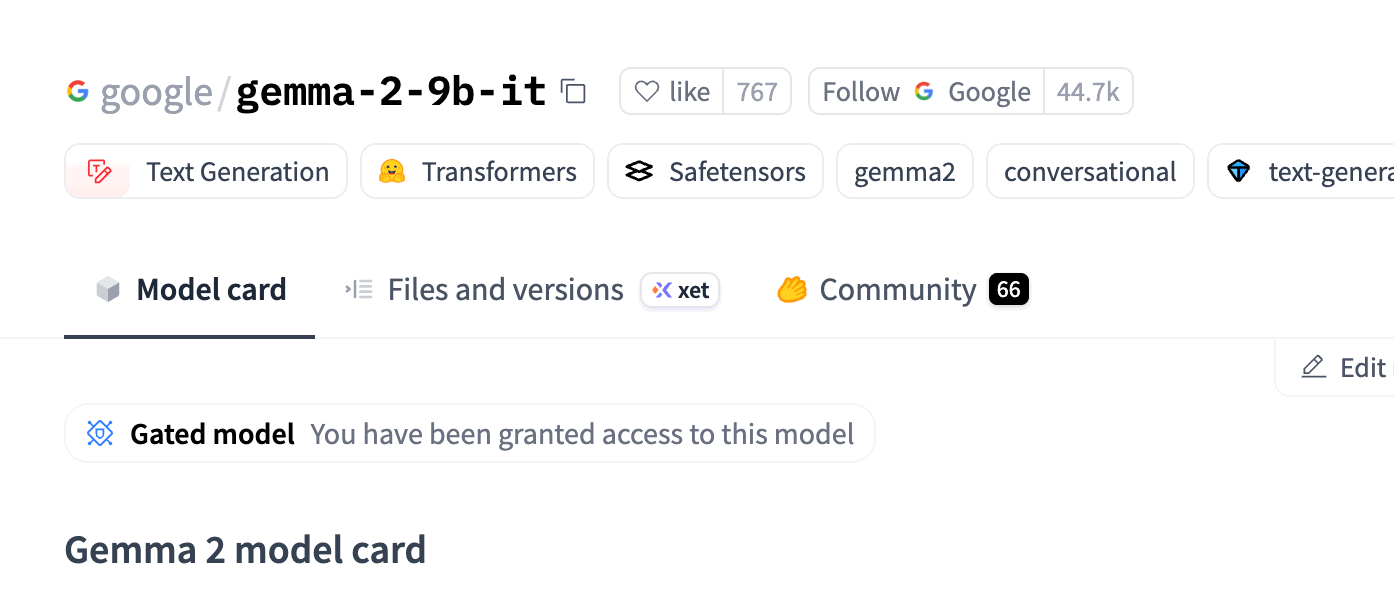

### 3.5.0. Setup

In [ ]:
!pip install -q -U transformers
!pip install -q -U accelerate
!pip install -q -U bitsandbytes
!pip install -q -U datasets==3.6.0

In [ ]:
#help track which versions of libraries we're using
!pip list | grep transformers
!pip list | grep accelerate
!pip list | grep bitsandbytes
!pip list | grep datasets

In [ ]:
import datasets
from transformers import pipeline, BitsAndBytesConfig
import bitsandbytes as bnb
import torch
import random
import pandas as pd
from tqdm import tqdm


In [ ]:
!pip install -q evaluate
import evaluate

In [ ]:
!pip install -q rouge_score

In [ ]:
#let's make longer output readable without horizontal scrolling
from pprint import pprint

Now let's get the data we're going to use.

In [ ]:
#import datasets
#import random
#import torch
from datasets import load_dataset

def load_and_sample_dataset(num_samples=11):
    """
    Load and sample records from the X-Sum dataset
    """
    #dataset = datasets.load_dataset("xsum", split="train", cache_dir=None, trust_remote_code=True)

    dataset = load_dataset("EdinburghNLP/xsum", split="test")
    selected_indices = random.sample(range(len(dataset)), num_samples)
    selected_samples = dataset.select(selected_indices)
    return selected_samples

In [ ]:
# Set random seed for reproducibility
random.seed(42)
torch.manual_seed(42)

# Load dataset
print("Loading dataset...")
dataset = load_and_sample_dataset()

In [ ]:
display(dataset)

What do our input documents lok like?  Let's see the first of them.

In [ ]:
dataset[0]['document']

And what does the corresponding summmary look like?  This is our target.

In [ ]:
dataset[0]['summary']

We'll also take advantage of a Hugging Face abstraction called a pipeline.  It is an easy way of experimenting with a model in inference mode.  We'll use that here to experiment with prompts (and possibly some hyperparameters) to imporve the quality of our results.

It takes a while to load this model -- on the order of ten minutes -- but once it is loaded you can keep reusing the loaded model and improve your prompt.



In [ ]:
"""
Initialize the pipeline with bitsandbytes quantization
"""
# Configure bitsandbytes for 4-bit quantization
quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16
)

# Initialize pipeline
model_id = "google/gemma-2-9b-it"

summarizer = pipeline(
   "text-generation",
   model=model_id,
   model_kwargs={"dtype": torch.bfloat16, "quantization_config": quantization_config},
   device_map="auto",
   trust_remote_code=True,
)

As a reminder, here's the record we're dealing with.

In [ ]:
dataset[0]

Let's just generate one summary so we can see what it looks like

In [ ]:
prompt = [
            {"role": "user", "content": "Generate a summary of this text: " + dataset[0]['document']}
        ]



outputs = summarizer(
  prompt,
  max_new_tokens=256,
  do_sample = True,
  temperature = 0.3,
  top_p = 0.95
)

summary = outputs[0]["generated_text"][-1]

Let's see what the generated summary looks like.

In [ ]:
summary

How does it compare with the reference? Let's compare your candidate and the reference using the ROUGE metric.

In [ ]:
rouge = evaluate.load('rouge')


# Process each sample
print("Generating summaries and calculating ROUGE scores...")



# Calculate ROUGE scores
predictions = [summary['content']]
references = [[dataset[0]['summary']]]
rouge_scores = rouge.compute(predictions=predictions, references=references)
rouge_scores

### 3.5.1 Generation and Evaluation

Now, it's your turn.  Please improve the prompt below so that you get output that, when scored using ROUGE, the average scores for the entire data sample of 11 records exceeds these thresholds:
* Rouge-1 > 0.22
* Rouge-2 > 0.04
* Rouge-L > 0.16

You may use sampling with Top K or Top P and termperature if you like but the prompt is what will have the greatest effect on your output.  Your prompt should give as specific instructions as possible.  These LLMs are trained to follow instructions so be very specific in your request.  Individual words can make a large difference so take a little time to experiment with synonyms and alternate ways of phrasing things.

In [ ]:
# Store results for aggregate scoring
results = []

Enter your prompt in the space below and then run the code.  

In [ ]:
dataset[6]

In [ ]:
for idx, sample in enumerate(tqdm(dataset)):
    try:
      prompt = [
      ### YOUR CODE HERE




      ### END YOUR CODE
              ]


      # Generate summary via the pipeline
      outputs = summarizer(
                          prompt,
                          max_new_tokens=512,
                 ### YOUR CODE HERE




                 ### END YOUR CODE

      )

      summary = outputs[0]["generated_text"][-1]

      # Calculate ROUGE scores
      predictions = [summary['content']]
      references = [[sample['summary']]]
      rouge_scores = rouge.compute(predictions=predictions, references=references)


      # Store results
      results.append({
          'id': idx,
          'original_text': sample['document'][:500],  # Store truncated text for readability
          'reference_summary': sample['summary'],
          'generated_summary': summary,
           **rouge_scores
      })

      # Print progress update every 10 samples
      if (idx + 1) % 10 == 0:
          print(f"\nProcessed {idx + 1} samples")
          print(f"Latest ROUGE-1: {rouge_scores['rouge1']:.4f}")

    except Exception as e:
      print(f"Error processing sample {idx}: {str(e)}")
      continue

Calculate and print the average scores.

In [ ]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)

# Calculate and print average ROUGE scores
avg_scores = results_df[['rouge1', 'rouge2', 'rougeL']].mean()
print("\nAverage ROUGE Scores:")
for metric, score in avg_scores.items():
   print(f"{metric}: {score:.4f}")

# Print some example summaries
print("\nExample Summaries:")
for i in range(min(5, len(results_df))):
   print(f"\nExample {i+1}:")
   print(f"Reference: {results_df.iloc[i]['reference_summary']}")
   print(f"Generated: {results_df.iloc[i]['generated_summary']}")

**QUESTION:**

3.5.1.1 (3 pt) What is the number of words in your prompt once you've met the scoring criteria?



In [ ]:
### --- Put your answer in Gradescope Q.29. Do not enter your answer here. --- ###

**QUESTION:**

3.5.1.2 (1 pt) What is the avg ROUGE-1 score you get once you've met the scoring criteria?



In [ ]:
### --- Put your answer in Gradescope Q.30. Do not enter your answer here. --- ###

**QUESTION:**

3.5.1.3 (2 pt) What is the avg ROUGE-2 score you get once you've met the scoring criteria?



In [ ]:
### --- Put your answer in Gradescope Q.31. Do not enter your answer here. --- ###

**QUESTION:**

3.5.1.4 (2 pt) How helpful do you find ROUGE to be in creating better summaries?  How do you think it could be improved? Please write a five sentence response in the text cell below.

In [ ]:
### --- Put your answer in Gradescope Q.32. Do not enter your answer here. --- ###

## AI Citation Section

"Explain error", Gemini 3.5 Flash in Colab, Google, 2026-10-05


To complete the assignment, download this completed notebook as an .ipynb file to your laptop and then upload that .ipynb file into Gradescope using the final question in the naswer sheet.  We expect to find a file named Assignment_3.ipynb in Gradescope associated with you.

**It is your responsibility to make sure that you have uploaded the correct file with your code, the outputs of running your code and other cells.  We will grade you based on a combination of the answer cells and the code and output of the code you have written.**